In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

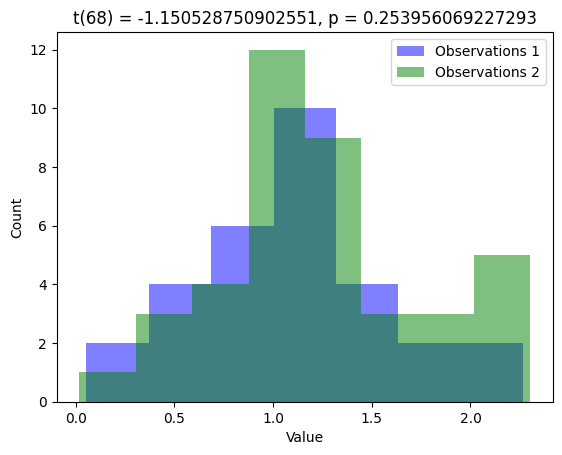

In [11]:
n1 = 30
n2 = 40

pop_mean1 = 1
pop_mean2 = 1.2

variance = .5

observations_1 = pop_mean1 + np.random.randn(n1) * variance
observations_2 = pop_mean2 + np.random.randn(n2) * variance

t, p = stats.ttest_ind(observations_1, observations_2, equal_var=True)

plt.hist(observations_1, bins='fd', color='blue', alpha=0.5, label='Observations 1')
plt.hist(observations_2, bins='fd', color='green', alpha=0.5, label='Observations 2')
plt.xlabel('Value')
plt.ylabel('Count')
plt.title(f"t({n1 + n2 - 2}) = {t}, p = {p}")
plt.legend()

plt.show()

## 2D map of t values

In [12]:
mean_differences = np.linspace(-3, 3, 80)
pooled_variances = np.linspace(.5, 4, 100)

n1 = 40
n2 = 30

t_values = np.zeros((len(mean_differences), len(pooled_variances)))

for index_diff, diff in enumerate(mean_differences):
    for index_var, var in enumerate(pooled_variances):

        # t-value denominator
        degrees_of_freedom = n1 + n2 - 2
        s = np.sqrt(( (n1-1) * var + (n2-1) * var ) / degrees_of_freedom)
        denominator = s * np.sqrt(1/n1 + 1/n2)

        # t-value in the matrix
        t_values[index_diff, index_var] = diff / denominator

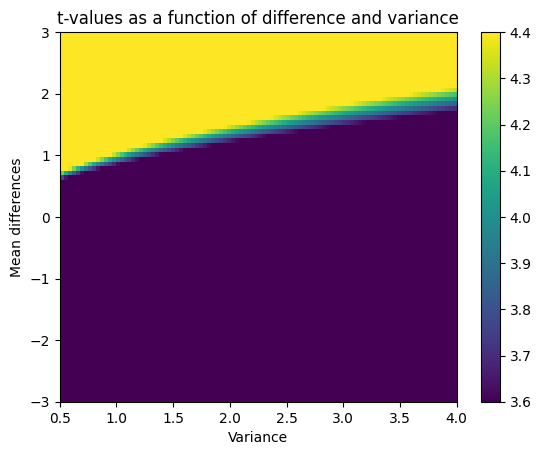

In [13]:


plt.imshow(
    t_values,
    vmin=4,
    vmax=4,
    extent=(pooled_variances[0], pooled_variances[-1], mean_differences[0], mean_differences[-1]),
    origin='lower',
    aspect='auto'
)

plt.title('t-values as a function of difference and variance')
plt.xlabel('Variance')
plt.ylabel('Mean differences')
plt.colorbar()

plt.show()
